# Superstore Sales & Profit Analysis

## Problem Statement

The objective of this project is to analyze sales, profit, discounts,
regions, categories, and customer segments to identify important
business trends and areas of strong and weak performance.

## Tools & Technologies

- Python
- Pandas
- NumPy
- Matplotlib
- Seaborn
- Jupyter Notebook

In [102]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 1. Load and Understand the Dataset

### Dataset Overview

The dataset contains information about orders, customers, products,
sales, discounts, and profit.

In [86]:
df = pd.read_csv("Sample_Superstore.csv")
df.head()

,Order Date,Ship Mode,Segment,Region,Category,Sub-Category,City,Quantity,Discount,Sales,Profit
0,2017-01-01,Same Day,Consumer,West,Office Supplies,Art,Los Angeles,3,0.10,93.57,7.25
1,2017-01-01,Standard Class,Corporate,West,Furniture,Bookcases,Seattle,1,0.15,130.50,-5.51
2,2017-01-01,Second Class,Consumer,Central,Office Supplies,Art,Dallas,9,0.10,342.72,72.98
3,2017-01-01,Standard Class,Consumer,West,Technology,Accessories,San Francisco,3,0.10,533.31,51.24
4,2017-01-01,First Class,Consumer,East,Office Supplies,Paper,Philadelphia,4,0.00,378.83,78.78


In [83]:
df.shape

(9994, 12)

In [3]:
df.columns

Index(['Order Date', 'Ship Mode', 'Segment', 'Region', 'Category',
       'Sub-Category', 'City', 'Quantity', 'Discount', 'Sales', 'Profit'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9997 entries, 0 to 9996
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   Order Date    9997 non-null   str    
 1   Ship Mode     9987 non-null   str    
 2   Segment       9997 non-null   str    
 3   Region        9997 non-null   str    
 4   Category      9997 non-null   str    
 5   Sub-Category  9997 non-null   str    
 6   City          9987 non-null   str    
 7   Quantity      9997 non-null   int64  
 8   Discount      9997 non-null   float64
 9   Sales         9997 non-null   float64
 10  Profit        9997 non-null   float64
dtypes: float64(3), int64(1), str(7)
memory usage: 1.5 MB


In [5]:
df.describe()

,Quantity,Discount,Sales,Profit
count,9997.000000,9997.000000,9997.000000,9997.000000
mean,5.054816,0.120766,602.260298,57.286862
std,2.581329,0.109799,751.616439,126.374450
min,1.000000,0.000000,7.620000,-455.220000
25%,3.000000,0.000000,168.670000,3.690000
50%,5.000000,0.100000,346.310000,22.720000
75%,7.000000,0.200000,727.790000,65.390000
max,9.000000,0.400000,11474.180000,1722.160000


### Data Understanding

The dataset contains 9,997 records and 11 columns.

It includes information related to order dates, shipping methods,
customer segments, regions, product categories, cities, quantities,
discounts, sales, and profit.

The dataset contains both categorical and numerical variables,
which makes it suitable for exploratory data analysis.

## 2. Data Cleaning

### 2.1 Check for Missing Values

First, we will identify whether the dataset contains any missing values.

In [6]:
df.isnull().sum()

Order Date       0
Ship Mode       10
Segment          0
Region           0
Category         0
Sub-Category     0
City            10
Quantity         0
Discount         0
Sales            0
Profit           0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(3)

### 2.2 Handling Missing Values

The dataset contains 20 missing values in total:
- 10 missing values in `Ship Mode`
- 10 missing values in `City`

Since both columns are categorical, the missing values will be replaced
using the mode (most frequently occurring value) of each column.

In [13]:
df["Ship Mode"].value_counts()

Ship Mode
Standard Class    6013
Second Class      1974
First Class       1513
Same Day           484
Name: count, dtype: int64

In [14]:
df["City"].value_counts()

City
Seattle          800
Los Angeles      777
Philadelphia     760
Denver           750
San Francisco    749
Columbus         738
Boston           737
New York City    734
Dallas           597
Houston          584
Chicago          578
Minneapolis      573
Miami            437
Nashville        403
Atlanta          390
Charlotte        377
Name: count, dtype: int64

In [96]:
df["Ship Mode"] = df["Ship Mode"].fillna(df["Ship Mode"].mode()[0])

In [97]:
df["City"] = df["City"].fillna(df["City"].mode()[0])

In [98]:
df.isnull().sum()

Order Date      0
Ship Mode       0
Segment         0
Region          0
Category        0
Sub-Category    0
City            0
Quantity        0
Discount        0
Sales           0
Profit          0
dtype: int64

### 2.3 Handling Duplicate Records

Duplicate records can affect the accuracy of our analysis.
We will identify and remove duplicate rows from the dataset.

In [93]:
df.duplicated().sum()

np.int64(0)

In [94]:
df.drop_duplicates(inplace=True)

### 2.4 Convert Data Types

The `Order Date` column is currently stored as a text/object data type.
Since it represents dates, we will convert it to a datetime format for
future date-based analysis.

In [99]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [100]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   Order Date    9994 non-null   datetime64[us]
 1   Ship Mode     9994 non-null   str           
 2   Segment       9994 non-null   str           
 3   Region        9994 non-null   str           
 4   Category      9994 non-null   str           
 5   Sub-Category  9994 non-null   str           
 6   City          9994 non-null   str           
 7   Quantity      9994 non-null   int64         
 8   Discount      9994 non-null   float64       
 9   Sales         9994 non-null   float64       
 10  Profit        9994 non-null   float64       
dtypes: datetime64[us](1), float64(3), int64(1), str(6)
memory usage: 1.4 MB


### 2.5 Final Data Quality Check

After handling missing values, removing duplicates, and converting the
date column, we will perform a final check to ensure that the dataset
is ready for analysis.

In [101]:
print("Missing values:")
print(df.isnull().sum())

print("\nDuplicate rows:", df.duplicated().sum())

print("\nDataset shape:", df.shape)

Missing values:
Order Date      0
Ship Mode       0
Segment         0
Region          0
Category        0
Sub-Category    0
City            0
Quantity        0
Discount        0
Sales           0
Profit          0
dtype: int64

Duplicate rows: 0

Dataset shape: (9994, 11)


# 3. Exploratory Data Analysis (EDA)

## 3.1 Univariate Analysis

### Numerical Variable Distributions

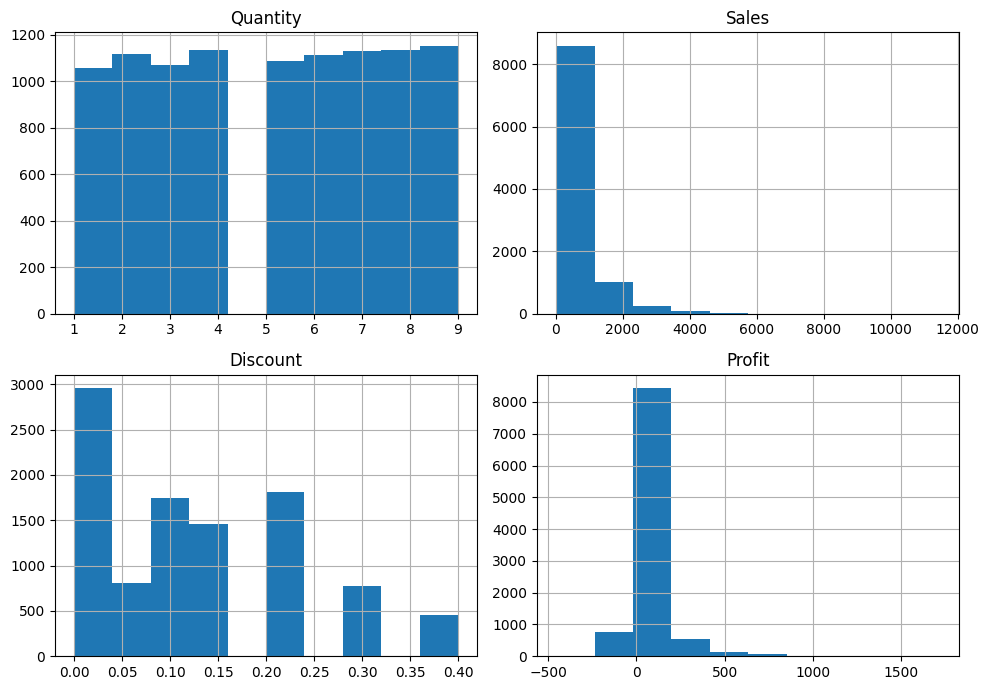

In [103]:
df[["Quantity","Sales","Discount","Profit"]].hist(figsize=(10,7))
plt.tight_layout()
plt.show()

### Categorical Variable Analysis

In [28]:
df["Category"].value_counts()

Category
Office Supplies    5982
Furniture          2061
Technology         1951
Name: count, dtype: int64

### Category Distribution

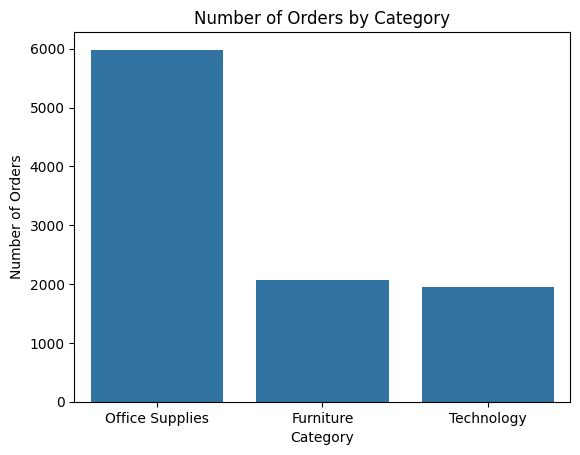

In [31]:
sns.countplot(x="Category",data=df)
plt.title("Number of Orders by Category")
plt.xlabel("Category")
plt.ylabel("Number of Orders")
plt.show()

### Region Distribution

In [32]:
df["Region"].value_counts()

Region
West       3078
East       2972
Central    2335
South      1609
Name: count, dtype: int64

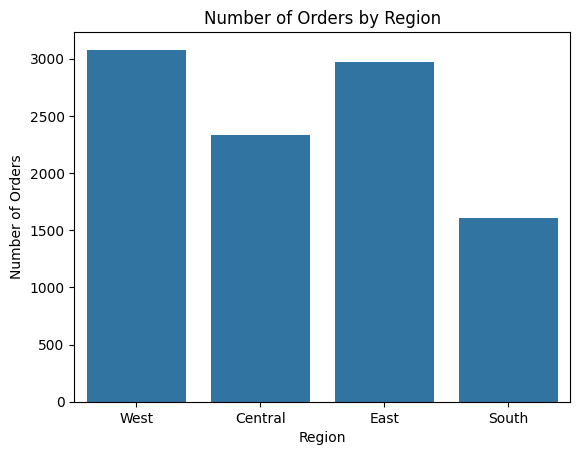

In [33]:
sns.countplot(x="Region",data=df)
plt.title("Number of Orders by Region")
plt.xlabel("Region")
plt.ylabel("Number of Orders")
plt.show()

### Segment Distribution

In [34]:
df["Segment"].value_counts()

Segment
Consumer       5242
Corporate      3010
Home Office    1742
Name: count, dtype: int64

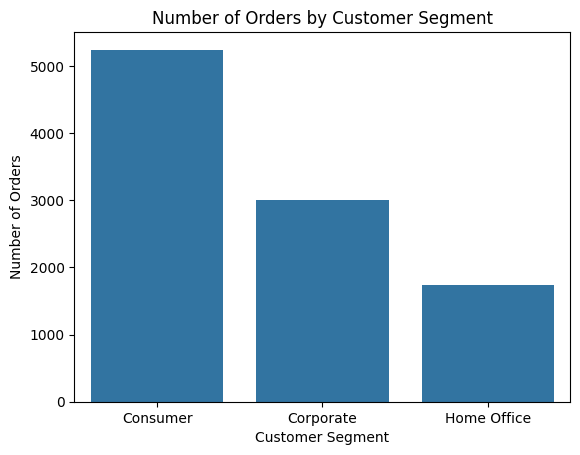

In [35]:
sns.countplot(x="Segment",data=df)
plt.title("Number of Orders by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Number of Orders")
plt.show()

### Sub-Category Distribution

In [37]:
subcat_counts = df["Sub-Category"].value_counts()

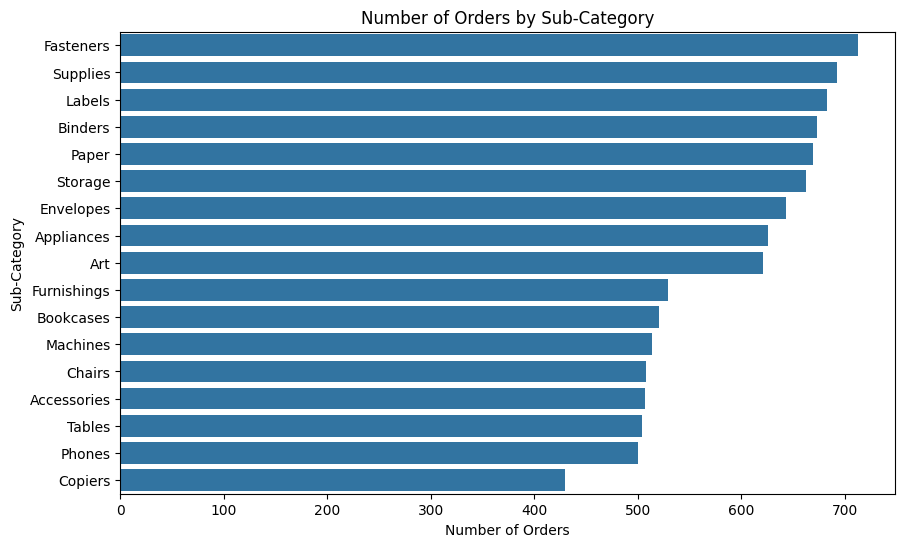

In [38]:
plt.figure(figsize=(10,6))
sns.barplot(x=subcat_counts.values,
            y=subcat_counts.index
           )
plt.title("Number of Orders by Sub-Category")
plt.xlabel("Number of Orders")
plt.ylabel("Sub-Category")
plt.show()

## 3.2 Bivariate Analysis

### Sales vs Profit

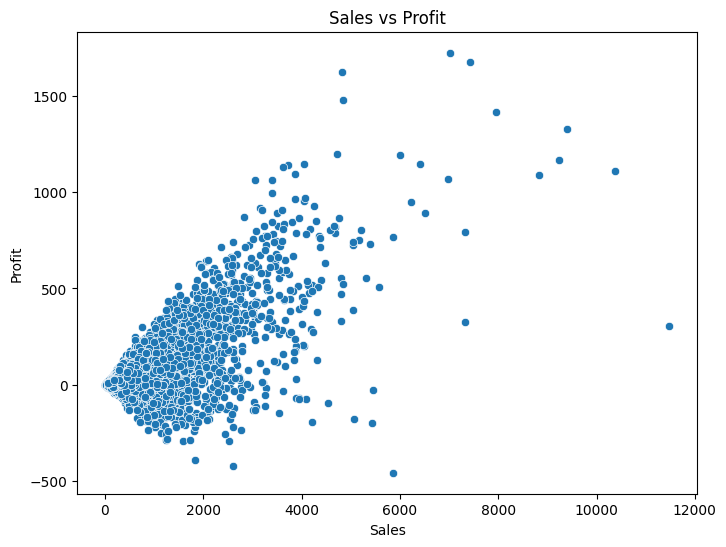

In [39]:
plt.figure(figsize=(8,6))
sns.scatterplot(x="Sales",y="Profit",data=df)
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

### Category-wise Sales

In [41]:
category_sales = df.groupby("Category")["Sales"].sum().sort_values(ascending=False)
category_sales

Category
Technology         2486861.15
Furniture          1820143.61
Office Supplies    1710249.79
Name: Sales, dtype: float64

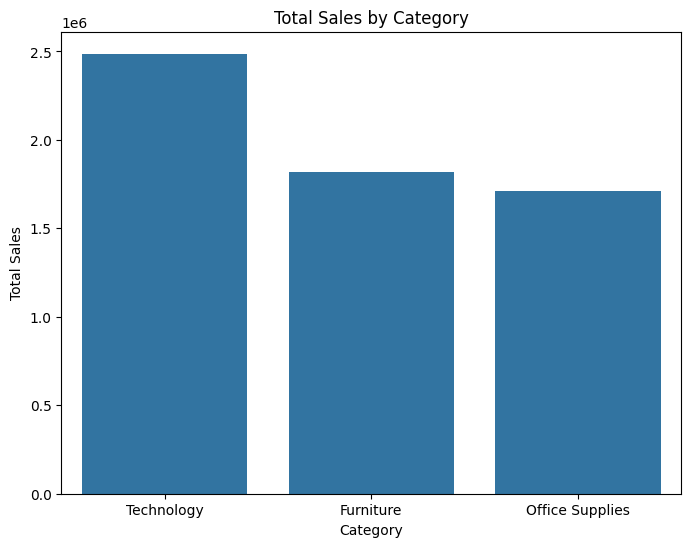

In [42]:
plt.figure(figsize=(8,6))
sns.barplot(x=category_sales.index,
            y=category_sales.values
           )
plt.title("Total Sales by Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")
plt.show()

### Category-wise Profit

In [43]:
category_profit = df.groupby("Category")["Profit"].sum().sort_values(ascending=False)
category_profit

Category
Technology         354558.31
Office Supplies    176328.07
Furniture           41637.51
Name: Profit, dtype: float64

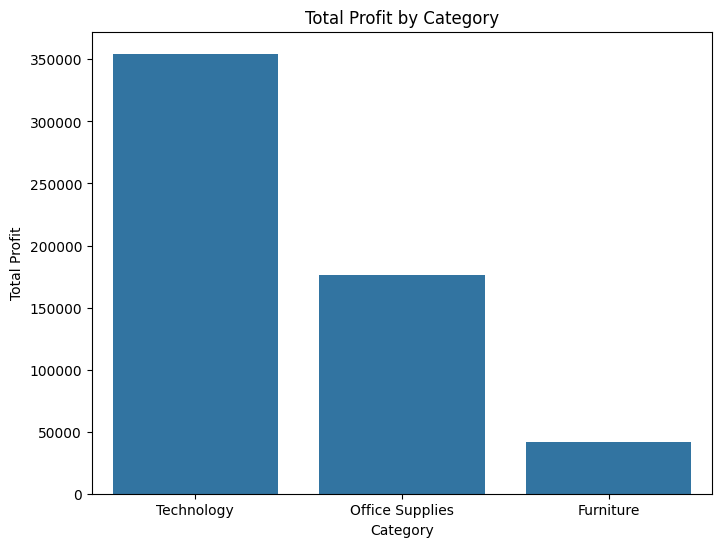

In [44]:
plt.figure(figsize=(8,6))
sns.barplot(x=category_profit.index,
            y=category_profit.values
           )
plt.title("Total Profit by Category")
plt.xlabel("Category")
plt.ylabel("Total Profit")
plt.show()

### Region-wise Profit

In [45]:
region_profit = df.groupby("Region")["Profit"].sum().sort_values(ascending=False)
region_profit

Region
East       169690.65
West       165878.91
Central    140861.29
South       96093.04
Name: Profit, dtype: float64

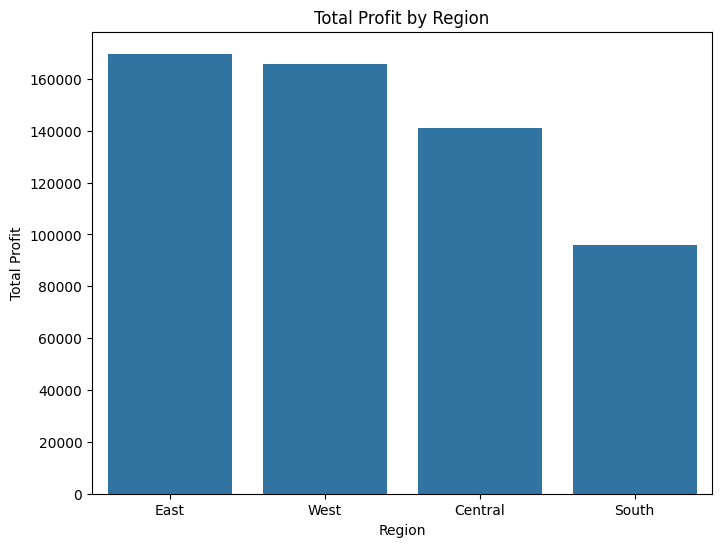

In [46]:
plt.figure(figsize=(8,6))
sns.barplot(x=region_profit.index,
            y=region_profit.values
           )
plt.title("Total Profit by Region")
plt.xlabel("Region")
plt.ylabel("Total Profit")
plt.show()

### Discount vs Profit

In [47]:
discount_profit = df.groupby("Discount")["Profit"].sum().sort_values(ascending=False)
discount_profit

Discount
0.00    311603.29
0.10    106143.61
0.05     67331.78
0.15     59891.22
0.20     43542.73
0.30     -2148.01
0.40    -13840.73
Name: Profit, dtype: float64

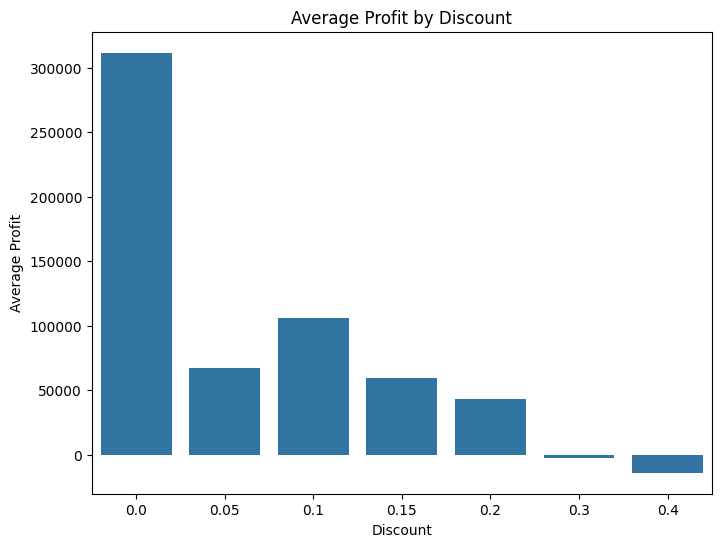

In [48]:
plt.figure(figsize=(8,6))
sns.barplot(x=discount_profit.index,
            y=discount_profit.values
           )
plt.title("Average Profit by Discount")
plt.xlabel("Discount")
plt.ylabel("Average Profit")
plt.show()

### Segment-wise Sales

In [49]:
segment_sales = df.groupby("Segment")["Sales"].sum().sort_values(ascending=False)

segment_sales

Segment
Consumer       3143077.74
Corporate      1831670.27
Home Office    1042506.54
Name: Sales, dtype: float64

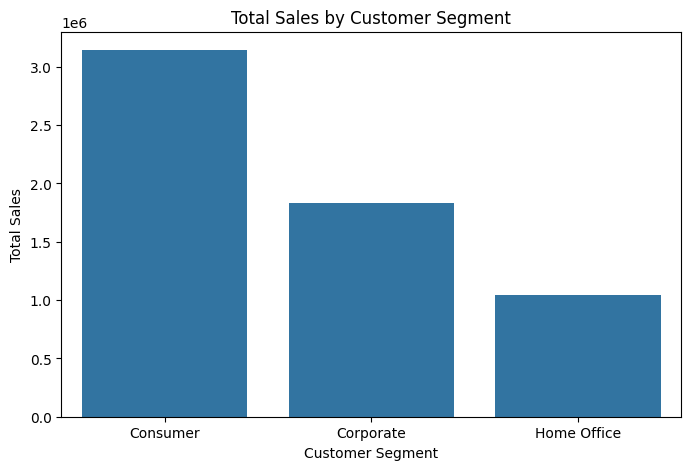

In [50]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=segment_sales.index,
    y=segment_sales.values
)

plt.title("Total Sales by Customer Segment")
plt.xlabel("Customer Segment")
plt.ylabel("Total Sales")
plt.show()

### Region-wise Category Sales

In [51]:
category_region_sales = pd.pivot_table(df,
                                       index="Region",
                                       values="Sales",
                                       columns="Category",
                                       aggfunc="sum"
                                      )
category_region_sales

Category,Furniture,Office Supplies,Technology
Region,,,
Central,393368.40,397687.26,618557.64
East,577843.33,506236.15,722586.58
South,293344.00,268928.40,429092.83
West,555587.88,537397.98,716624.10


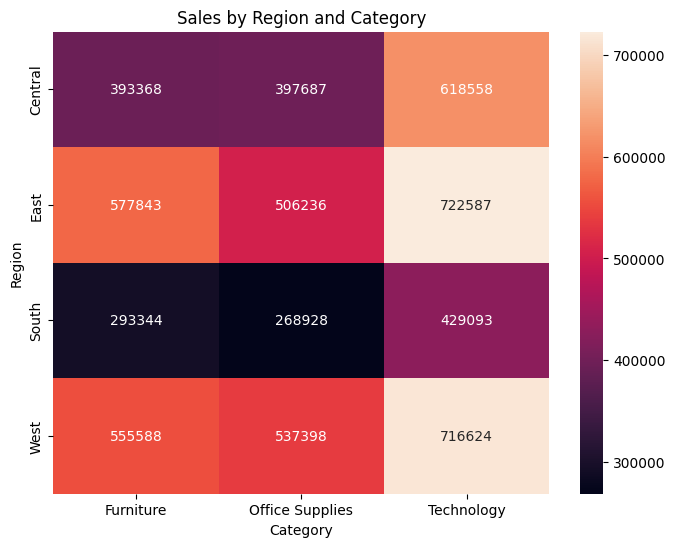

In [52]:
plt.figure(figsize=(8,6))
sns.heatmap(category_region_sales,annot=True,fmt=".0f")
plt.title("Sales by Region and Category")
plt.xlabel("Category")
plt.ylabel("Region")
plt.show()

### Sub-Category-wise Profit

In [55]:
subcategory_profit = (df.groupby("Sub-Category")["Profit"].sum().sort_values())
subcategory_profit

Sub-Category
Tables          9333.40
Chairs          9674.70
Bookcases       9765.31
Furnishings    12864.10
Envelopes      18072.88
Art            18205.94
Appliances     18810.89
Labels         19463.88
Binders        19587.18
Paper          19878.74
Storage        19907.56
Supplies       21154.12
Fasteners      21246.88
Copiers        78440.08
Accessories    90109.67
Machines       92813.28
Phones         93195.28
Name: Profit, dtype: float64

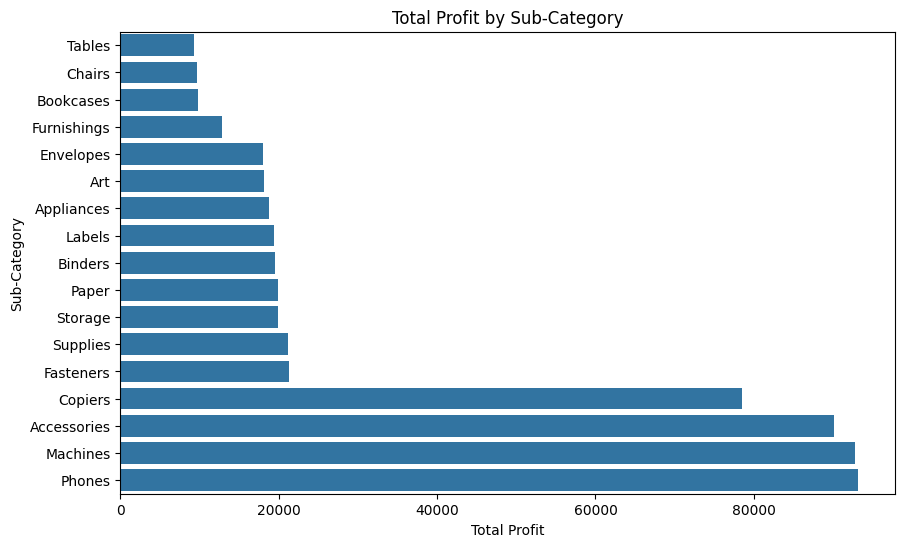

In [62]:
plt.figure(figsize=(10,6))
sns.barplot(x=subcategory_profit.values,
            y=subcategory_profit.index
           )
plt.title("Total Profit by Sub-Category")
plt.xlabel("Total Profit")
plt.ylabel("Sub-Category")
plt.show()

In [63]:
df[df["Sub-Category"] == "Tables"][["Sales","Profit","Discount"]].describe()

,Sales,Profit,Discount
count,504.000000,504.000000,504.000000
mean,896.661052,18.518651,0.117857
std,733.779683,96.256181,0.105413
min,53.850000,-388.490000,0.000000
25%,391.442500,-21.992500,0.000000
50%,755.525000,9.215000,0.100000
75%,1167.607500,49.945000,0.200000
max,5435.750000,659.440000,0.400000


In [64]:
df[df["Sub-Category"] == "Phones"][["Sales", "Profit", "Discount"]].describe()

,Sales,Profit,Discount
count,500.000000,500.000000,500.000000
mean,1309.080260,186.390560,0.116800
std,1171.010745,204.064607,0.109872
min,61.690000,-133.020000,0.000000
25%,564.230000,47.265000,0.000000
50%,1011.065000,124.260000,0.100000
75%,1724.832500,267.445000,0.200000
max,11474.180000,1189.940000,0.400000


### Profit Margin Analysis

In [65]:
df["Profit Margin"] = (df["Profit"] / df["Sales"]) * 100

In [66]:
subcategory_margin = (df.groupby("Sub-Category")["Profit Margin"]).sum().sort_values(ascending=False)
subcategory_margin

Sub-Category
Phones         7054.673656
Accessories    6914.804641
Fasteners      6910.177394
Machines       6823.999031
Supplies       6742.564982
Storage        6596.061510
Labels         6536.848340
Binders        6464.167112
Paper          6160.281166
Copiers        5998.459859
Appliances     5880.383788
Envelopes      5724.699519
Art            5550.303464
Tables          763.715892
Furnishings     700.290308
Chairs          470.545791
Bookcases       318.636569
Name: Profit Margin, dtype: float64

### Discount vs Profit Margin

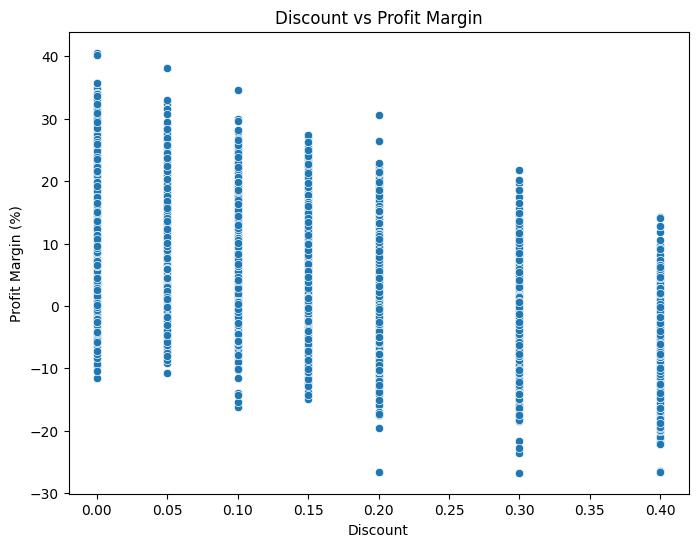

In [67]:
plt.figure(figsize=(8,6))

sns.scatterplot(
    x="Discount",
    y="Profit Margin",
    data=df
)

plt.title("Discount vs Profit Margin")
plt.xlabel("Discount")
plt.ylabel("Profit Margin (%)")
plt.show()

### Correlation Analysis

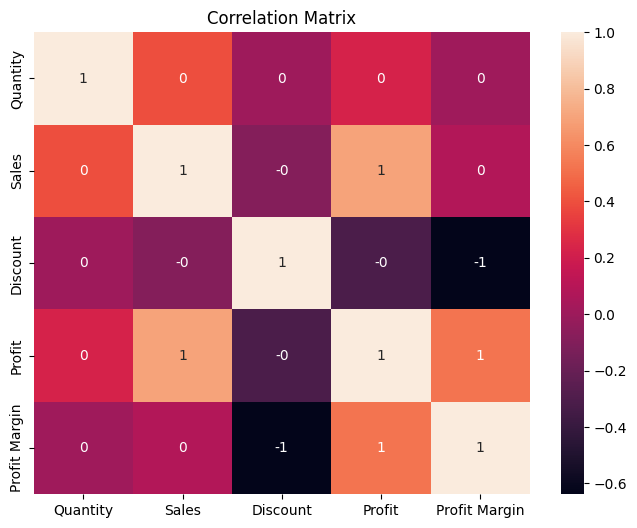

In [69]:
corr = df[["Quantity","Sales","Discount","Profit","Profit Margin"]].corr()
plt.figure(figsize=(8,6))
sns.heatmap(corr,annot=True,fmt=".0f")
plt.title("Correlation Matrix")
plt.show()

In [70]:
region_analysis = df.groupby("Region")[["Sales", "Profit"]].sum().sort_values("Sales", ascending=False)

region_analysis

,Sales,Profit
Region,,
West,1809609.96,165878.91
East,1806666.06,169690.65
Central,1409613.30,140861.29
South,991365.23,96093.04


In [71]:
category_analysis = df.groupby("Category").agg(
    Total_Sales=("Sales", "sum"),
    Average_Profit=("Profit", "mean")
)

category_analysis

,Total_Sales,Average_Profit
Category,,
Furniture,1820143.61,20.202576
Office Supplies,1710249.79,29.476441
Technology,2486861.15,181.731579


In [72]:
category_discount = df.groupby("Category").agg(
    Average_Discount=("Discount", "mean"),
    Average_Profit=("Profit", "mean")
)

category_discount

,Average_Discount,Average_Profit
Category,,
Furniture,0.122004,20.202576
Office Supplies,0.120027,29.476441
Technology,0.121861,181.731579


In [73]:
subcat_analysis = df.groupby("Sub-Category").agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
).sort_values("Total_Sales", ascending=False)

subcat_analysis

,Total_Sales,Total_Profit
Sub-Category,,
Machines,658178.40,92813.28
Phones,654540.13,93195.28
Accessories,639805.21,90109.67
Copiers,534337.41,78440.08
Furnishings,489555.32,12864.10
Bookcases,452655.69,9765.31
Tables,451917.17,9333.40
Chairs,426015.43,9674.70
Fasteners,205701.89,21246.88


In [74]:
region_category_profit = pd.pivot_table(
    df,
    values="Profit",
    index="Region",
    columns="Category",
    aggfunc="sum"
)

region_category_profit

Category,Furniture,Office Supplies,Technology
Region,,,
Central,11774.15,40175.96,88911.18
East,12028.53,51827.00,105835.12
South,5873.35,28345.09,61874.60
West,11961.48,55980.02,97937.41


In [75]:
region_category = df.groupby(["Region", "Category"]).agg(
    Total_Sales=("Sales", "sum"),
    Avg_Profit_Margin=("Profit Margin", "mean")
)

region_category.sort_values("Total_Sales", ascending=False)

Total_Sales  Avg_Profit_Margin
Region  Category                                       
East    Technology         722586.58          13.705660
West    Technology         716624.10          13.402612
Central Technology         618557.64          13.947532
East    Furniture          577843.33           0.927017
West    Furniture          555587.88           0.823765
        Office Supplies    537397.98           9.521310
East    Office Supplies    506236.15           9.317122
South   Technology         429092.83          14.074569
Central Office Supplies    397687.26           9.306019
        Furniture          393368.40           1.739324
South   Furniture          293344.00           1.008282
        Office Supplies    268928.40           9.797576

In [79]:
loss_orders = (df[df["Profit"] < 0].groupby("Sub-Category").size().sort_values(ascending=False))
loss_orders

Sub-Category
Bookcases      241
Chairs         228
Furnishings    219
Tables         209
Envelopes      104
Art            103
Paper          100
Binders         98
Fasteners       98
Supplies        92
Labels          89
Appliances      83
Storage         81
Machines        38
Accessories     37
Copiers         33
Phones          33
dtype: int64

In [80]:
quantity_profit = df.groupby("Quantity")["Profit"].mean().sort_index()

quantity_profit

Quantity
1    12.602161
2    21.634324
3    36.567914
4    46.028404
5    58.172684
6    58.126577
7    85.094916
8    97.621242
9    94.398038
Name: Profit, dtype: float64

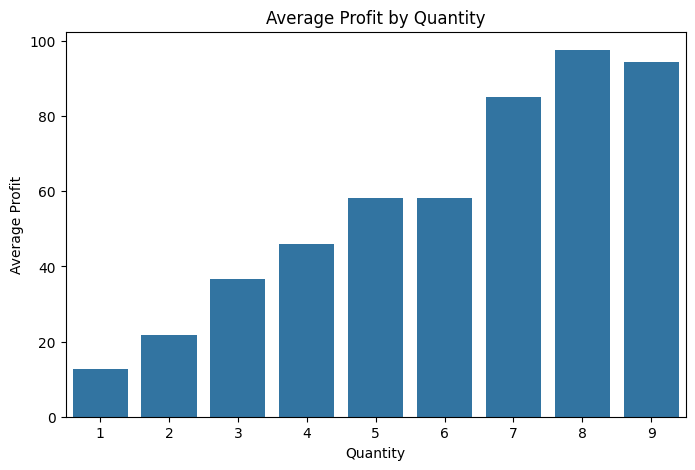

In [81]:
plt.figure(figsize=(8,5))
sns.barplot(x=quantity_profit.index, y=quantity_profit.values)
plt.title("Average Profit by Quantity")
plt.xlabel("Quantity")
plt.ylabel("Average Profit")
plt.show()

In [82]:
segment_category = df.groupby(["Segment", "Category"]).agg(
    Total_Sales=("Sales", "sum"),
    Total_Profit=("Profit", "sum")
)

segment_category

Total_Sales  Total_Profit
Segment     Category                                  
Consumer    Furniture          949920.91      23809.91
            Office Supplies    885839.89      91003.71
            Technology        1307316.94     187362.23
Corporate   Furniture          554437.46       9631.04
            Office Supplies    518797.91      54516.91
            Technology         758434.90     108566.61
Home Office Furniture          315785.24       8196.56
            Office Supplies    305611.99      30807.45
            Technology         421109.31      58629.47

# 4. Key Business Insights

### Key Findings

- West generated the highest total sales, while East generated the highest total profit.
- Technology was the highest-performing category in terms of total sales and total profit.
- Furniture had the lowest average profit and the highest average discount among the categories.
- Phones generated the highest total profit among the sub-categories, while Tables generated the lowest.
- Higher discounts were associated with lower profit margins.
- East + Technology generated the highest profit among Region–Category combinations.
- South + Furniture generated the lowest profit among Region–Category combinations.
- Consumer + Technology generated the highest sales and profit among Segment–Category combinations.

# 5. Conclusion

The analysis provided insights into sales, profit, discounts, regions,
categories, sub-categories, and customer segments. Technology emerged as
a strong-performing category, while differences between sales and profit
across regions highlighted the importance of evaluating profitability
alongside revenue. The analysis also showed an association between higher
discounts and lower profit margins.